# ChemTab UQ-II Benchmark Notebook %FLAMES (4 Cpv) Strategy
### This notebook contains experiments around Stacking and other Strategies
#### Amol Salunkhe

# Includes & Helper Functions

In [259]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge, LinearRegression
from sklearn import gaussian_process
from sklearn.gaussian_process import GaussianProcessRegressor
import scipy.optimize
from sklearn.utils.optimize import _check_optimize_result
from sklearn.gaussian_process.kernels import Matern, RBF, WhiteKernel, RationalQuadratic, ExpSineSquared
import time
from sklearn.decomposition import PCA, SparsePCA
%matplotlib inline
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing
import tensorflow_probability as tfp
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers, activations, initializers, constraints, Sequential
from tensorflow.keras.constraints import UnitNorm, Constraint
import sys
import tikzplotlib
# libraries and data
plt.style.use('seaborn')
encoding_dim = 4
cpv_cols = ["Cpv"+str(i+1) for i in range (encoding_dim)]

In [260]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Error [All Souspecs + Souener]')
    plt.legend()
    plt.grid(True)

In [261]:
def getResiduals(Y_test,Y_pred):
    evaluation_df_1 = pd.DataFrame()

    evaluation_df_1['actual'] = Y_test.flatten()

    evaluation_df_1['prediction'] = Y_pred.flatten()

    evaluation_df_1['res'] = evaluation_df_1['actual'] - evaluation_df_1['prediction'] 
   
    return evaluation_df_1['res'].values


In [262]:
dependents = ["souener","souspecO2", "souspecCO", "souspecCO2", "souspecH2O", "souspecOH", "souspecH2", "souspecCH4"]
std_dev_dependents = ['std_dev_' + dependent for dependent in dependents]
phytrackers = ["X_bins","flame_key_int"]

In [263]:
# patient early stopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=45)
from tensorflow.keras import regularizers, activations, initializers, constraints, Sequential
from tensorflow.keras.constraints import UnitNorm, Constraint
from tensorflow.keras import backend as K

In [264]:
def get_predictions(model,dataset,model_type='encoder_regressor',evaluation_type='test'):
    if model_type =='encoder_regressor':
        if evaluation_type =='test':
            Zmix_test =  dataset["Zmix_test"]
            normalized_species_test = dataset["normalized_species_test"]
            predictions = model.predict([normalized_species_test,Zmix_test])
        #assuming this is the 'complete' data set evaluation
        elif evaluation_type =='train':
            Zmix_train =  dataset["Zmix_train"]
            normalized_species_train = dataset["normalized_species_train"]
            predictions = model.predict([normalized_species_train,Zmix_train])
        else:
            Zmix_all =  dataset["Zmix_all"]
            normalized_species_all = dataset["normalized_species_test"]
            predictions = model.predict([normalized_species_all,Zmix_all])
    else:
        if evaluation_type =='test':
            cpvs_zmix_test = dataset["cpvs_zmix_test"]
            predictions = model.predict(cpvs_zmix_test)
        #assuming this is the 'complete' data set evaluation
        elif evaluation_type =='train':
            cpvs_zmix_train = dataset["cpvs_zmix_train"]
            predictions = model.predict(cpvs_zmix_train)
        else:
            cpvs_zmix_all = dataset["cpvs_zmix_all"]
            predictions = model.predict(cpvs_zmix_all)
    return predictions

def evaluate_model(model,dataset,model_type='encoder_regressor',evaluation_type='test', ensemble=False):
    
    scaler_souener = dataset["scaler_souener"]
    
    if evaluation_type =='test':
        Y_true_df = pd.DataFrame(data=dataset["Y_test"],  columns=dependents)
    elif evaluation_type =='train':
        Y_true_df = pd.DataFrame(data=dataset["Y_train"],  columns=dependents)
    else:
        Y_true_df = pd.DataFrame(data=dataset["Y_all"],  columns=dependents)
        
    if ensemble == True:
        ensemble_predictions = []
        for sub_model in model:
            predictions = get_predictions(sub_model,dataset,model_type,evaluation_type)
            #ensemble_predictions.append(predictions)
            ensemble_predictions.append(scaler_souener.inverse_transform(predictions))
        predictions = np.average(ensemble_predictions, axis=0)
        predictions_variance = np.var(ensemble_predictions, axis=0)
        predictions_std = np.std(ensemble_predictions, axis=0)  
        Y_pred = predictions
        Y_pred_df = pd.DataFrame(data=Y_pred,  columns=dependents)
        Y_pred_df[std_dev_dependents] = predictions_std#np.sqrt(np.absolute(Y_pred_variance))

    else:
        predictions = get_predictions(model,dataset,model_type,evaluation_type)
        Y_pred = scaler_souener.inverse_transform(predictions)
        Y_pred_df = pd.DataFrame(data=Y_pred,  columns=dependents)
    
    err_df = computeErrorAcrossDependents(Y_pred_df, Y_true_df)
        
    return err_df,Y_true_df,Y_pred_df
    

def addLinearEncodedProgVarsToDataSet(linear_encoder_model,dataset):
    dataset["cpvs_test"] = linear_encoder_model.predict(dataset["normalized_species_test"])
    
    dataset["cpvs_zmix_test"] = np.append(np.reshape(dataset["Zmix_test"], (-1, 1)),dataset["cpvs_test"],axis=1)
    
    dataset["cpvs_all"] = linear_encoder_model.predict(dataset["normalized_species_all"])

    dataset["cpvs_zmix_all"] = np.append(np.reshape(dataset["Zmix_all"], (-1, 1)),dataset["cpvs_all"],axis=1)
    return dataset

In [265]:
def computeError (Y_pred, Y_test):
    evaluation_df_1 = pd.DataFrame()

    evaluation_df_1['souener'] = Y_test.flatten()

    evaluation_df_1['souener_pred'] = Y_pred.flatten()

    evaluation_df_1['souener_pred_L1'] = evaluation_df_1['souener'] - evaluation_df_1['souener_pred'] 

    evaluation_df_1['souener_pred_L2'] = evaluation_df_1['souener_pred_L1'] * evaluation_df_1['souener_pred_L1']
    
    evaluation_df_1['souener_pred_L1Percent'] = ((evaluation_df_1['souener'] - evaluation_df_1['souener_pred'])/evaluation_df_1['souener']) 
    
    TotalAbsoluteError = evaluation_df_1['souener_pred_L1'].abs().sum()

    TotalSquaredError = evaluation_df_1['souener_pred_L2'].abs().sum()
    
    MeanAbsoluteError = evaluation_df_1['souener_pred_L1'].abs().sum()/evaluation_df_1['souener_pred_L1'].abs().count()

    MeanSquaredError = evaluation_df_1['souener_pred_L2'].abs().sum()/evaluation_df_1['souener_pred_L2'].abs().count()
    
    NumPoints = evaluation_df_1['souener_pred_L1Percent'].abs().count()
    
    MeanPercentageError = evaluation_df_1['souener_pred_L1Percent'].abs().sum()/NumPoints
    
    return [MeanAbsoluteError,TotalAbsoluteError,MeanPercentageError,MeanSquaredError,TotalSquaredError,NumPoints]

def printError (err):
    MeanAbsoluteError = err[0]
    TotalAbsoluteError = err[1]
    MeanPercentageError = err[2]
    MeanSquaredError = err[3]
    TotalSquaredError = err[4]
    NumPoints = err[5]
    print ('Total Absolute Error: ', TotalAbsoluteError)
    print ('Mean Absolute Error: ', MeanAbsoluteError)
    print ('Mean Percentage Error: ', MeanPercentageError)
    print ('Total Squared Error: ', TotalSquaredError)
    print ('Mean Squared Error: ', MeanSquaredError)
    print ('Number of Points: ', NumPoints)

def computeAndPrintError(Y_pred, Y_test):    
    err = computeError (Y_pred, Y_test)
    printError (err)
    return err

def computeErrorAcrossDependents(Y_pred_df, Y_test_df):    
    err_data = []
    for dependent in dependents:
        Y_pred = Y_pred_df[dependent].values
        Y_test = Y_test_df[dependent].values
        err = computeError (Y_pred, Y_test)
        err.insert(0,dependent)
        err_data.append(err)
    err_df = pd.DataFrame(data=err_data, columns=["Dependent","Mean ABS","Total ABS","Mean Pct Err","Mean SSE","Total SSE", "#Pts" ])
    err_df.drop(columns=["Mean Pct Err","Mean SSE","Total SSE"], inplace=True)
    return err_df

def create_residual_df(Y_pred_df,Y_true_df,evaluation_type='all',residuals_for="souener"):
    if evaluation_type=='all':
        flame_keys_col = 'flame_keys_all'
        Xpos_bins_col = 'Xpos_bins_all'
    elif  evaluation_type=='train':
        flame_keys_col = 'flame_keys_train'
        Xpos_bins_col = 'Xpos_bins_train'
    else:
        flame_keys_col = 'flame_keys_test'
        Xpos_bins_col = 'Xpos_bins_test'
        
    residual_df = pd.DataFrame(data=Y_pred_df[residuals_for].values,columns=["pred"])
    residual_df["true"] = Y_true_df[residuals_for].values
    residual_df["flame_key_str"] = np.array(["%.8f" % w for w in dataset[flame_keys_col]])
    residual_df["Xpos_bins"] = dataset[Xpos_bins_col]
    residual_df['residual'] = residual_df["true"] - residual_df["pred"]
    residual_df['residual_abs'] = residual_df['residual'].abs()
    return residual_df

In [266]:
def curate_flame_plot_data(dataset,Y_true_df,Y_pred_df,depenent_name="souener",ensemble=False):
    dataset_df = pd.DataFrame(data=dataset["Y_all"],columns=dependents)
    dataset_df[depenent_name+"_pred"] = Y_pred_df[depenent_name].values
    if ensemble==True:
        dataset_df["upper_limit"] = Y_pred_df[depenent_name].values + 1.96 * Y_pred_df["std_dev_"+depenent_name].values
        dataset_df["lower_limit"] = Y_pred_df[depenent_name].values - 1.96 * Y_pred_df["std_dev_"+depenent_name].values
    dataset_df["flame_key_str"] = np.array(["%.8f" % w for w in dataset["flame_keys_all"]])
    dataset_df["flame_keys"] = dataset["flame_keys_all"]
    dataset_df["Xpos"] = dataset["Xpos_all"]
    dataset_df["Xpos_bins"] = dataset["Xpos_bins_all"]
    return dataset_df

def curate_plot_data_for_all_dependents_for_a_flame(dataset,Y_true_df,Y_pred_df,ensemble=False):
    #print(ensemble)
    dataset_df = pd.DataFrame(data=dataset["Y_all"],columns=dependents)
    for depenent_name in dependents:
        dataset_df[depenent_name+"_pred"] = Y_pred_df[depenent_name].values
        if ensemble==True:
            #print (depenent_name)
            dataset_df["upper_limit_"+depenent_name] = Y_pred_df[depenent_name].values + 1.96 * Y_pred_df["std_dev_"+depenent_name].values
            dataset_df["lower_limit_"+depenent_name] = Y_pred_df[depenent_name].values - 1.96 * Y_pred_df["std_dev_"+depenent_name].values
    dataset_df["flame_key_str"] = np.array(["%.8f" % w for w in dataset["flame_keys_all"]])
    dataset_df["flame_keys"] = dataset["flame_keys_all"]
    dataset_df["Xpos"] = dataset["Xpos_all"]
    dataset_df["Xpos_bins"] = dataset["Xpos_bins_all"]
    return dataset_df

def plot_single_model_vs_ensemble_for_a_flame(flame_key,single_model_dataset_df,ensemble_dataset_df,
                rows=4,cols=4,figsize=(35,35),x_axis_col="Xpos", save_file=None):
    sns.set_theme(style="ticks")
    fig, ax = plt.subplots(rows, cols, figsize=figsize)
    lines = []
    for i in range(rows):
        for j in range(cols):
            #print(((i*4)+j))
            depenent_name = dependents[((i*4)+j)//2]
            true_col = depenent_name
            pred_col = depenent_name + "_pred"
            title = ""
            upper_limit_col = "upper_limit_"+depenent_name 
            lower_limit_col = "lower_limit_"+depenent_name 
            #Single Model is Odd
            if ((i*4)+j) % 2 == 0:
                temp_df = single_model_dataset_df[single_model_dataset_df['flame_key_str'] == flame_key][[true_col, pred_col, x_axis_col]].sort_values(by=[x_axis_col])                
                title = "Single Model " + depenent_name
            else:
                temp_df = ensemble_dataset_df[ensemble_dataset_df['flame_key_str'] == flame_key][[true_col, pred_col, upper_limit_col, lower_limit_col, x_axis_col]].sort_values(by=[x_axis_col])
                title = "Deep Ensemble " + depenent_name
                
            #Plot the bands
            if ((i*4)+j) % 2 > 0:
                #print("Ccame Here")
                stddev_prediction_label_color = ax[i, j].fill_between(
                    temp_df[x_axis_col].values,
                    temp_df[upper_limit_col].values,
                    temp_df[lower_limit_col].values,
                    alpha=0.1,
                    color='blue',
                    label=r"95% confidence interval"
                    
                )
                lines.append(stddev_prediction_label_color)
            
            #Plot the Prediction
            prediction_label_color = ax[i, j].plot(temp_df[x_axis_col].values,temp_df[pred_col].values, 'b--',label='pred', linewidth=2 )
            lines.append(prediction_label_color)
            
            #Plot the True Label
            true_label_color = ax[i, j].plot(temp_df[x_axis_col].values,temp_df[true_col].values,'r--', label='true', linewidth=2)
            lines.append(true_label_color)
            
            ax[i, j].title.set_text(title)
    
    if save_file != None:
        tikzplotlib.save(save_file)


def plot_flames(high_res_flames,dataset_df,rows=5,cols=2,figsize=(35,35),true_col ="souener"
                ,pred_col ="souener_pred",x_axis_col="Xpos",upper_limit_col="upper_limit"
                  ,lower_limit_col="lower_limit",ensemble=False, save_file=None):
    sns.set_theme(style="ticks")#sns.set_theme(style="dark")
    fig, ax = plt.subplots(rows, cols, sharex='col', sharey='row',figsize=figsize)
    lines = []
    for i in range(rows):
        for j in range(cols):
            #print((i*2)+j)
            flame_key = high_res_flames.keys()[(i*2)+j]
            if ensemble == True:
                temp_df = dataset_df[dataset_df['flame_key_str'] == flame_key][[true_col, pred_col, upper_limit_col, lower_limit_col, x_axis_col]].sort_values(by=[x_axis_col])
            else:
                temp_df = dataset_df[dataset_df['flame_key_str'] == flame_key][[true_col, pred_col, x_axis_col]].sort_values(by=[x_axis_col])
            
            #Plot the bands
            if ensemble == True:
                #print("Ccame Here")
                stddev_prediction_label_color = ax[i, j].fill_between(
                    temp_df[x_axis_col].values,
                    temp_df[upper_limit_col].values,
                    temp_df[lower_limit_col].values,
                    alpha=0.1,
                    color='blue',
                    label=r"95% confidence interval"
                    
                )
                lines.append(stddev_prediction_label_color)
            
            #Plot the Prediction
            prediction_label_color = ax[i, j].plot(temp_df[x_axis_col].values,temp_df[pred_col].values, 'b--',label='pred', linewidth=2 )
            lines.append(prediction_label_color)
            
            #Plot the True Label
            true_label_color = ax[i, j].plot(temp_df[x_axis_col].values,temp_df[true_col].values,'r--', label='true', linewidth=2)
            lines.append(true_label_color)
            
            
            
            ax[i, j].title.set_text('Flamelet Key = ' + flame_key)
    
    if save_file != None:
        tikzplotlib.save(save_file)
    


## Loading & Initialization

### Load Data set and (pre)Trained Regressor Model

In [268]:
# load model from file
from tensorflow.keras.models import load_model
split_strategy= "points"#"flames"#"points"
filename = 'saved_models/regressor_'+split_strategy+'.h5'
regressor_model = load_model(filename)
import pickle
filename = 'uqdataset_'+split_strategy+'_0.8'
infile = open(filename,'rb')
dataset = pickle.load(infile)
infile.close()

### Hydrate the Dataset

In [269]:
fullerr_df,Y_true_df,Y_pred_df = evaluate_model(regressor_model,dataset,model_type='regressor',evaluation_type='all')
dataset_df = pd.DataFrame(data=dataset["Y_all"],columns=dependents)
dataset_df["souener_pred"] = Y_pred_df["souener"].values
dataset_df["flame_key_str"] = np.array(["%.8f" % w for w in dataset["flame_keys_all"]])
dataset_df["flame_keys"] = dataset["flame_keys_all"]
dataset_df["Xpos"] = dataset["Xpos_all"]
dataset_df["Xpos_bins"] = dataset["Xpos_bins_all"]
#dataset_df['residual'] = dataset_df["souener_true"] - dataset_df["souener_pred"]
#dataset_df['residual_abs'] = dataset_df['residual'].abs()





## (pre)Trained Regressor Model Analysis

### Plot the Residuals of the Single Model on Holdout Data

/Users/asalunkh/source_code/ChemTab/ChemTab/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:>

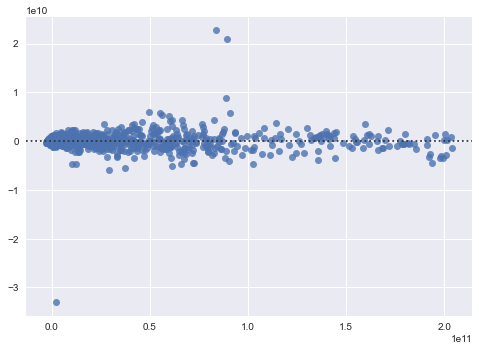

In [270]:
err_df,Y_true_df,Y_pred_df = evaluate_model(regressor_model,dataset,model_type='regressor',evaluation_type='test')
sns.residplot(Y_true_df["souener"].values, getResiduals(Y_true_df["souener"].values,Y_pred_df["souener"].values))

In [271]:
err_df

,Dependent,Mean ABS,Total ABS,#Pts
0,souener,4.679949e+08,1.539235e+12,3289
1,souspecO2,1.951080e+02,6.417101e+05,3289
2,souspecCO,3.353040e+01,1.102815e+05,3289
3,souspecCO2,3.011369e+01,9.904393e+04,3289
4,souspecH2O,3.879371e+01,1.275925e+05,3289
5,souspecOH,1.280294e+02,4.210887e+05,3289
6,souspecH2,9.770577e+00,3.213543e+04,3289
7,souspecCH4,4.241771e+01,1.395119e+05,3289


### Compute the Residuals on the Holdout Data for the Single Model by Flamelet and XPos

In [272]:
 np.unique(np.array(["%.8f" % w for w in dataset["flame_keys_test"]]))

array(['0.00020277', '0.00021344', '0.00022467', '0.00023650',
       '0.00024894', '0.00026205', '0.00027584', '0.00029035',
       '0.00030564', '0.00032172', '0.00033866', '0.00035648',
       '0.00037524', '0.00039499', '0.00041578', '0.00043766',
       '0.00046070', '0.00048495', '0.00051047', '0.00053734',
       '0.00056562', '0.00059539', '0.00062672', '0.00065971',
       '0.00069443', '0.00073098', '0.00076945', '0.00080995',
       '0.00085258', '0.00089745', '0.00094468', '0.00099440',
       '0.00104674', '0.00110183', '0.00115982', '0.00122087',
       '0.00128512', '0.00135276', '0.00142396', '0.00149890',
       '0.00157779', '0.00166083', '0.00174825', '0.00184026',
       '0.00193711', '0.00203907', '0.00214639', '0.00225936',
       '0.00237827', '0.00250344', '0.00263520', '0.00277390',
       '0.00291989', '0.00307357', '0.00323534'], dtype='<U10')

In [273]:

residual_df = create_residual_df(Y_pred_df,Y_true_df,evaluation_type='test',residuals_for="souener")

In [274]:
high_res_flames = residual_df.groupby("flame_key_str")["residual_abs"].sum().sort_values(ascending=False).head(10)

In [275]:
high_res_flames_df = pd.DataFrame({'ABS Residual' : residual_df.groupby("flame_key_str")["residual_abs"].sum().sort_values(ascending=False).head(10)}).reset_index()
high_res_flames_df

,flame_key_str,ABS Residual
0,0.00023650,7.904599e+10
1,0.00020277,6.357353e+10
2,0.00033866,6.025435e+10
3,0.00030564,5.756831e+10
4,0.00022467,5.533021e+10
5,0.00039499,5.167164e+10
6,0.00032172,5.037682e+10
7,0.00027584,4.817240e+10
8,0.00024894,4.783312e+10
9,0.00021344,4.749524e+10


In [276]:
print(high_res_flames_df.to_latex(index=False))  

\begin{tabular}{lr}
\toprule
flame\_key\_str &  ABS Residual \\
\midrule
   0.00023650 &  7.904599e+10 \\
   0.00020277 &  6.357353e+10 \\
   0.00033866 &  6.025435e+10 \\
   0.00030564 &  5.756831e+10 \\
   0.00022467 &  5.533021e+10 \\
   0.00039499 &  5.167164e+10 \\
   0.00032172 &  5.037682e+10 \\
   0.00027584 &  4.817240e+10 \\
   0.00024894 &  4.783312e+10 \\
   0.00021344 &  4.749524e+10 \\
\bottomrule
\end{tabular}



In [277]:
high_res_xpos_bins = residual_df.groupby("Xpos_bins")["residual_abs"].sum().sort_values(ascending=False)

In [278]:
high_res_xpos_bins_df = pd.DataFrame({'ABS Residual' : residual_df.groupby("Xpos_bins")["residual_abs"].sum().sort_values(ascending=False)}).reset_index()
high_res_xpos_bins_df

,Xpos_bins,ABS Residual
0,0.22 - 0.33,4.133929e+11
1,0.0 - 0.11,3.364565e+11
2,0.11 - 0.22,2.284694e+11
3,0.33 - 0.44,2.058881e+11
4,0.55 - 0.66,1.102133e+11
5,0.44 - 0.55,8.971007e+10
6,0.66 - 0.77,8.144498e+10
7,0.77 - 0.88,4.431664e+10
8,0.88 - 0.99,2.765116e+10
9,0.99 - 1.1,1.691913e+09


In [279]:
print(high_res_xpos_bins_df.to_latex(index=False))  

\begin{tabular}{lr}
\toprule
  Xpos\_bins &  ABS Residual \\
\midrule
0.22 - 0.33 &  4.133929e+11 \\
 0.0 - 0.11 &  3.364565e+11 \\
0.11 - 0.22 &  2.284694e+11 \\
0.33 - 0.44 &  2.058881e+11 \\
0.55 - 0.66 &  1.102133e+11 \\
0.44 - 0.55 &  8.971007e+10 \\
0.66 - 0.77 &  8.144498e+10 \\
0.77 - 0.88 &  4.431664e+10 \\
0.88 - 0.99 &  2.765116e+10 \\
 0.99 - 1.1 &  1.691913e+09 \\
\bottomrule
\end{tabular}



### Plot the Flamelet [Top 10 Residuals] {True, Prediction} 

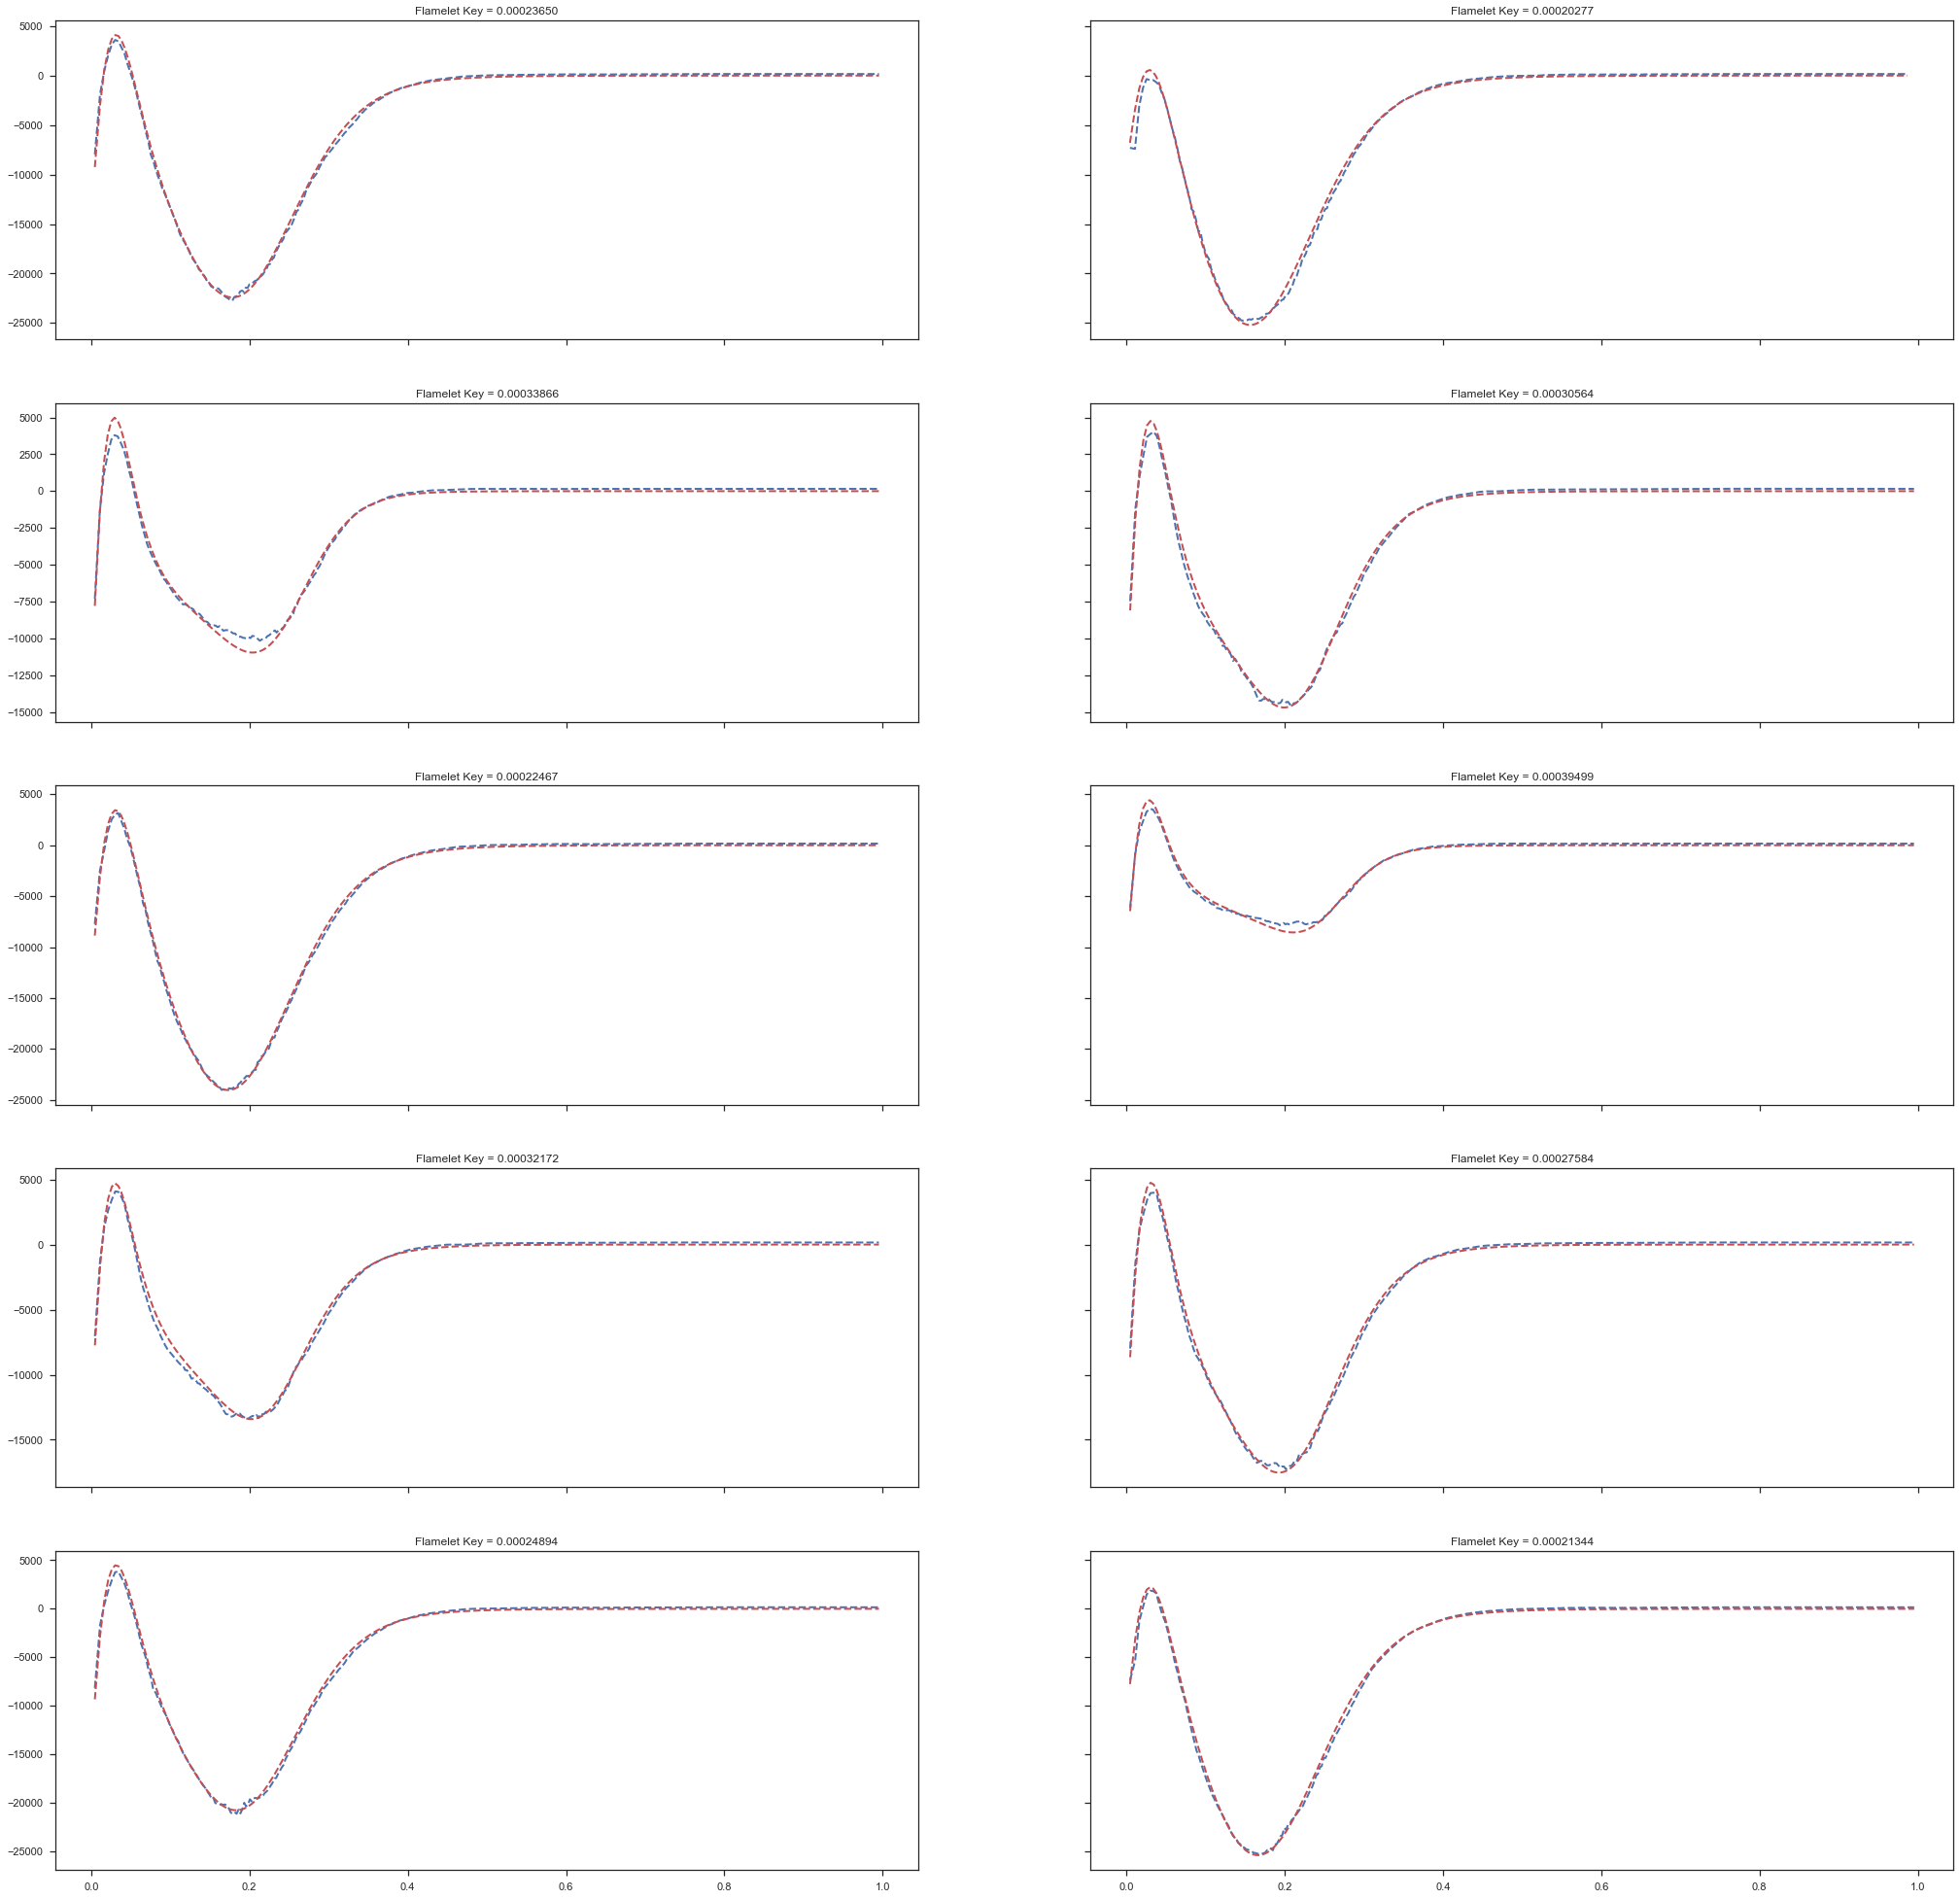

In [280]:
depenent_name = "souspecO2"
save_file_name = "plots/"+"single_model_"+ split_strategy +"_flame_"+depenent_name+".tex"
err_df,Y_true_df,Y_pred_df = evaluate_model(regressor_model,dataset,model_type='regressor',evaluation_type='all')
dataset_df = curate_flame_plot_data(dataset,Y_true_df,Y_pred_df,depenent_name=depenent_name)
plot_flames(high_res_flames,dataset_df,rows=5,cols=2,figsize=(35,35),true_col =depenent_name,pred_col =depenent_name+"_pred",x_axis_col="Xpos",upper_limit_col="upper_limit",lower_limit_col="lower_limit", save_file=save_file_name)



#plot_flames(high_res_flames,dataset_df,rows=5,cols=2,figsize=(35,35),true_col ="souener",pred_col ="souener_pred",x_axis_col="Xpos" )

In [281]:
single_model_dataset_df = curate_plot_data_for_all_dependents_for_a_flame(dataset,Y_true_df,Y_pred_df,ensemble=False)



### Plot the Xpos

In [282]:
'''
fig, ax = plt.subplots(5, 2, sharex='col', sharey='row',figsize=(35,35))
for i in range(5):
    for j in range(2):
        #print((i*2)+j)
        xpos_bin = high_res_xpos_bins.keys()[(i*2)+j]
        temp_df = dataset_df[dataset_df['Xpos_bins'] == xpos_bin][["souener", "souener_pred","flame_keys"]].sort_values(by=["flame_keys"])
        ax[i, j].plot(temp_df["flame_keys"].values,temp_df["souener"].values, label='true')
        ax[i, j].plot(temp_df["flame_keys"].values,temp_df["souener_pred"].values, label='pred')
        ax[i, j].grid(True)
'''

'\nfig, ax = plt.subplots(5, 2, sharex=\'col\', sharey=\'row\',figsize=(35,35))\nfor i in range(5):\n    for j in range(2):\n        #print((i*2)+j)\n        xpos_bin = high_res_xpos_bins.keys()[(i*2)+j]\n        temp_df = dataset_df[dataset_df[\'Xpos_bins\'] == xpos_bin][["souener", "souener_pred","flame_keys"]].sort_values(by=["flame_keys"])\n        ax[i, j].plot(temp_df["flame_keys"].values,temp_df["souener"].values, label=\'true\')\n        ax[i, j].plot(temp_df["flame_keys"].values,temp_df["souener_pred"].values, label=\'pred\')\n        ax[i, j].grid(True)\n'

In [283]:
#dataset.keys()

## Ensemble Analysis

### Ensemble Helper Functions

In [62]:
train_portion = 0.8
flame_keys = list(set(dataset['flame_key_ints_train']))
train_set_keys = flame_keys[:int(len(flame_keys)*train_portion)]


In [63]:
train_set = dataset["cpvs_zmix_train"][np.isin(dataset['flame_key_ints_train'], train_set_keys)]

In [284]:
def create_regresssor_ensemble (n_members,regressor_model):
    regressor_ensemble = [None]*n_members
    for i in range(n_members):
        regressor_ensemble[i] = tf.keras.models.clone_model(regressor_model)
        regressor_ensemble[i].set_weights(regressor_model.get_weights())
    return regressor_ensemble

def train_regresssor_ensemble (regressor_ensemble,dataset, split_strategy="points"):
    ensemble_history = []
    for i in range(len(regressor_ensemble)):
        regressor_ensemble[i].compile(loss='mean_absolute_error',optimizer=tf.keras.optimizers.Adam(0.001))
        
        train_portion = 0.8
        if split_strategy =="points":
            idx = np.random.choice(np.arange(len(dataset["cpvs_zmix_train"])), int (train_portion*len(dataset["cpvs_zmix_train"])), replace=False)
            cpvs_zmix_train = dataset["cpvs_zmix_train"][idx]
            Y_train = dataset["normalized_souener_train"][idx]
        else:
            flame_keys = list(set(dataset['flame_key_ints_train']))
            train_set_keys = flame_keys[:int(len(flame_keys)*train_portion)]
            cpvs_zmix_train = dataset["cpvs_zmix_train"][np.isin(dataset['flame_key_ints_train'], train_set_keys)]
            Y_train = dataset["normalized_souener_train"][np.isin(dataset['flame_key_ints_train'], train_set_keys)]
        
        
        print('--------------------------------------------------------------------------------------------')
        print('-------------------- Training Model '+ str(i) +' in the Ensemble ---------------------------')
        print('--------------------------------------------------------------------------------------------')
        history = regressor_ensemble[i].fit(cpvs_zmix_train, 
                              Y_train,
                              validation_split=0.2,
                              verbose=0, 
                              epochs=100, 
                              callbacks=[es])
        ensemble_history.append(history)
    return ensemble_history

#Plot Training History of the Ensemble
def plot_ensemble_train_history(ensemble_history):
    fig, ax = plt.subplots(5, 2, sharex='col', sharey='row',figsize=(35,35))
    for i in range(5):
        for j in range(2):
            #print((i*2)+j)
            history = ensemble_history[(i*2)+j].history
            ax[i, j].plot(history['loss'], label='loss')
            ax[i, j].plot(history['val_loss'], label='val_loss')
            ax[i, j].grid(True)

In [285]:
'''
err_df,Y_true_df,Y_pred_df = evaluate_model(regressor_ensemble,dataset,model_type='regressor',evaluation_type='test',ensemble=True)
sns.residplot(Y_true_df["souener"].values, getResiduals(Y_true_df["souener"].values,Y_pred_df["souener"].values))
'''

'\nerr_df,Y_true_df,Y_pred_df = evaluate_model(regressor_ensemble,dataset,model_type=\'regressor\',evaluation_type=\'test\',ensemble=True)\nsns.residplot(Y_true_df["souener"].values, getResiduals(Y_true_df["souener"].values,Y_pred_df["souener"].values))\n'

In [286]:
#err_df

In [287]:
def save_ensemble(ensemble,prefix):
    filenames = []
    for ndx,model in enumerate(ensemble):
        filename = prefix + '_' + str(ndx) +'.h5'
        model.save(filename)
        filenames.append(filename)
    return filenames

In [288]:

import os
def reload_ensembles(folder,ensemble_prefix):
    regressor_ensembles = {}
    for filename in os.listdir(folder):
        if filename.startswith(ensemble_prefix):
            #regressor_ensemble_flames_8_0.h5 --> 8_0
            n_members_model_num = filename[filename.index(ensemble_prefix) + len(ensemble_prefix):].replace('.h5', '')
            n_members = int(n_members_model_num.split('_')[0])
            model_num = int(n_members_model_num.split('_')[1])
            if n_members not in regressor_ensembles.keys():
                regressor_ensemble = [None]*n_members
                regressor_ensembles[n_members] = regressor_ensemble
            regressor_ensembles[n_members][model_num] = load_model(folder+filename)
            #print(filename)
    return regressor_ensembles

### Ablation study on the Size of the Ensemble

In [297]:
def run_ensemble_size_ablation(folder,ensemble_prefix):
    n_members_ablation = [2,4,6,8,10,12]
    ablation_results = {}
    regressor_ensembles = {}
    for n_members in n_members_ablation:
        regressor_ensemble = create_regresssor_ensemble (n_members, regressor_model)
        ablation_results[n_members] = {}
        ensemble_history = train_regresssor_ensemble (regressor_ensemble,dataset)
        regressor_ensembles[n_members]= regressor_ensemble
        prefix = folder + ensemble_prefix +'_'+str(n_members)
        filenames = save_ensemble(regressor_ensemble,prefix)
        err_df,Y_true_df,Y_pred_df = evaluate_model(regressor_ensemble,dataset,model_type='regressor',evaluation_type='test',ensemble=True)
        ablation_results[n_members]['regressor_ensemble_file_name']=filenames
        ablation_results[n_members]['ensemble_history']=ensemble_history
        ablation_results[n_members]['err_df'] = err_df
        ablation_results[n_members]['Y_true_df'] = Y_true_df
        ablation_results[n_members]['Y_pred_df'] = Y_pred_df
    return ablation_results

def reload_ensemble_ablation(folder,ensemble_prefix):
    ablation_results = {}
    regressor_ensembles = reload_ensembles(folder,ensemble_prefix)
    for n_members in regressor_ensembles:
        regressor_ensemble = regressor_ensembles[n_members]
        err_df,Y_true_df,Y_pred_df = evaluate_model(regressor_ensemble,dataset,model_type='regressor',evaluation_type='test',ensemble=True)
        if n_members not in ablation_results.keys():
            ablation_results[n_members] = {}    
        ablation_results[n_members]['err_df'] = err_df
        ablation_results[n_members]['Y_true_df'] = Y_true_df
        ablation_results[n_members]['Y_pred_df'] = Y_pred_df
    return ablation_results,regressor_ensembles



In [298]:
ensemble_prefix = 'regressor_ensemble_'+split_strategy+'_'
folder = "saved_models/"

#uncomment if we need to run ablation -- expensive operation
#ablation_results = run_ensemble_size_ablation(folder,ensemble_prefix)

ablation_results,regressor_ensembles = reload_ensemble_ablation(folder,ensemble_prefix)


In [299]:

def create_ablation_result_by_dependent(ablation_results,dependents):
    ablation_by_dependent = {}
    for i, dependent in enumerate(dependents):
        ablation_by_dependent[dependent] = []
        for j in n_members_ablation:
            ablation_by_dependent[dependent].append(ablation_results[j]['err_df']['Mean ABS'].values[i])
    return ablation_by_dependent

#Plot Ablation of the Ensemble
def plot_ensemble_ablation(ablation_by_dependent,dependents,n_members_ablation,save_file=None):
    fig, ax = plt.subplots(4, 2, figsize=(35,35))
    for i in range(4):
        for j in range(2):
            #print((i*2)+j)
            dependent = dependents[(i*2)+j]
            ax[i, j].plot(n_members_ablation,ablation_by_dependent[dependent], label=dependent)
            ax[i, j].title.set_text(dependent)
            ax[i, j].grid(True)
            if save_file != None:
                tikzplotlib.save(save_file)

In [300]:
ablation_by_dependent = create_ablation_result_by_dependent(ablation_results,dependents)

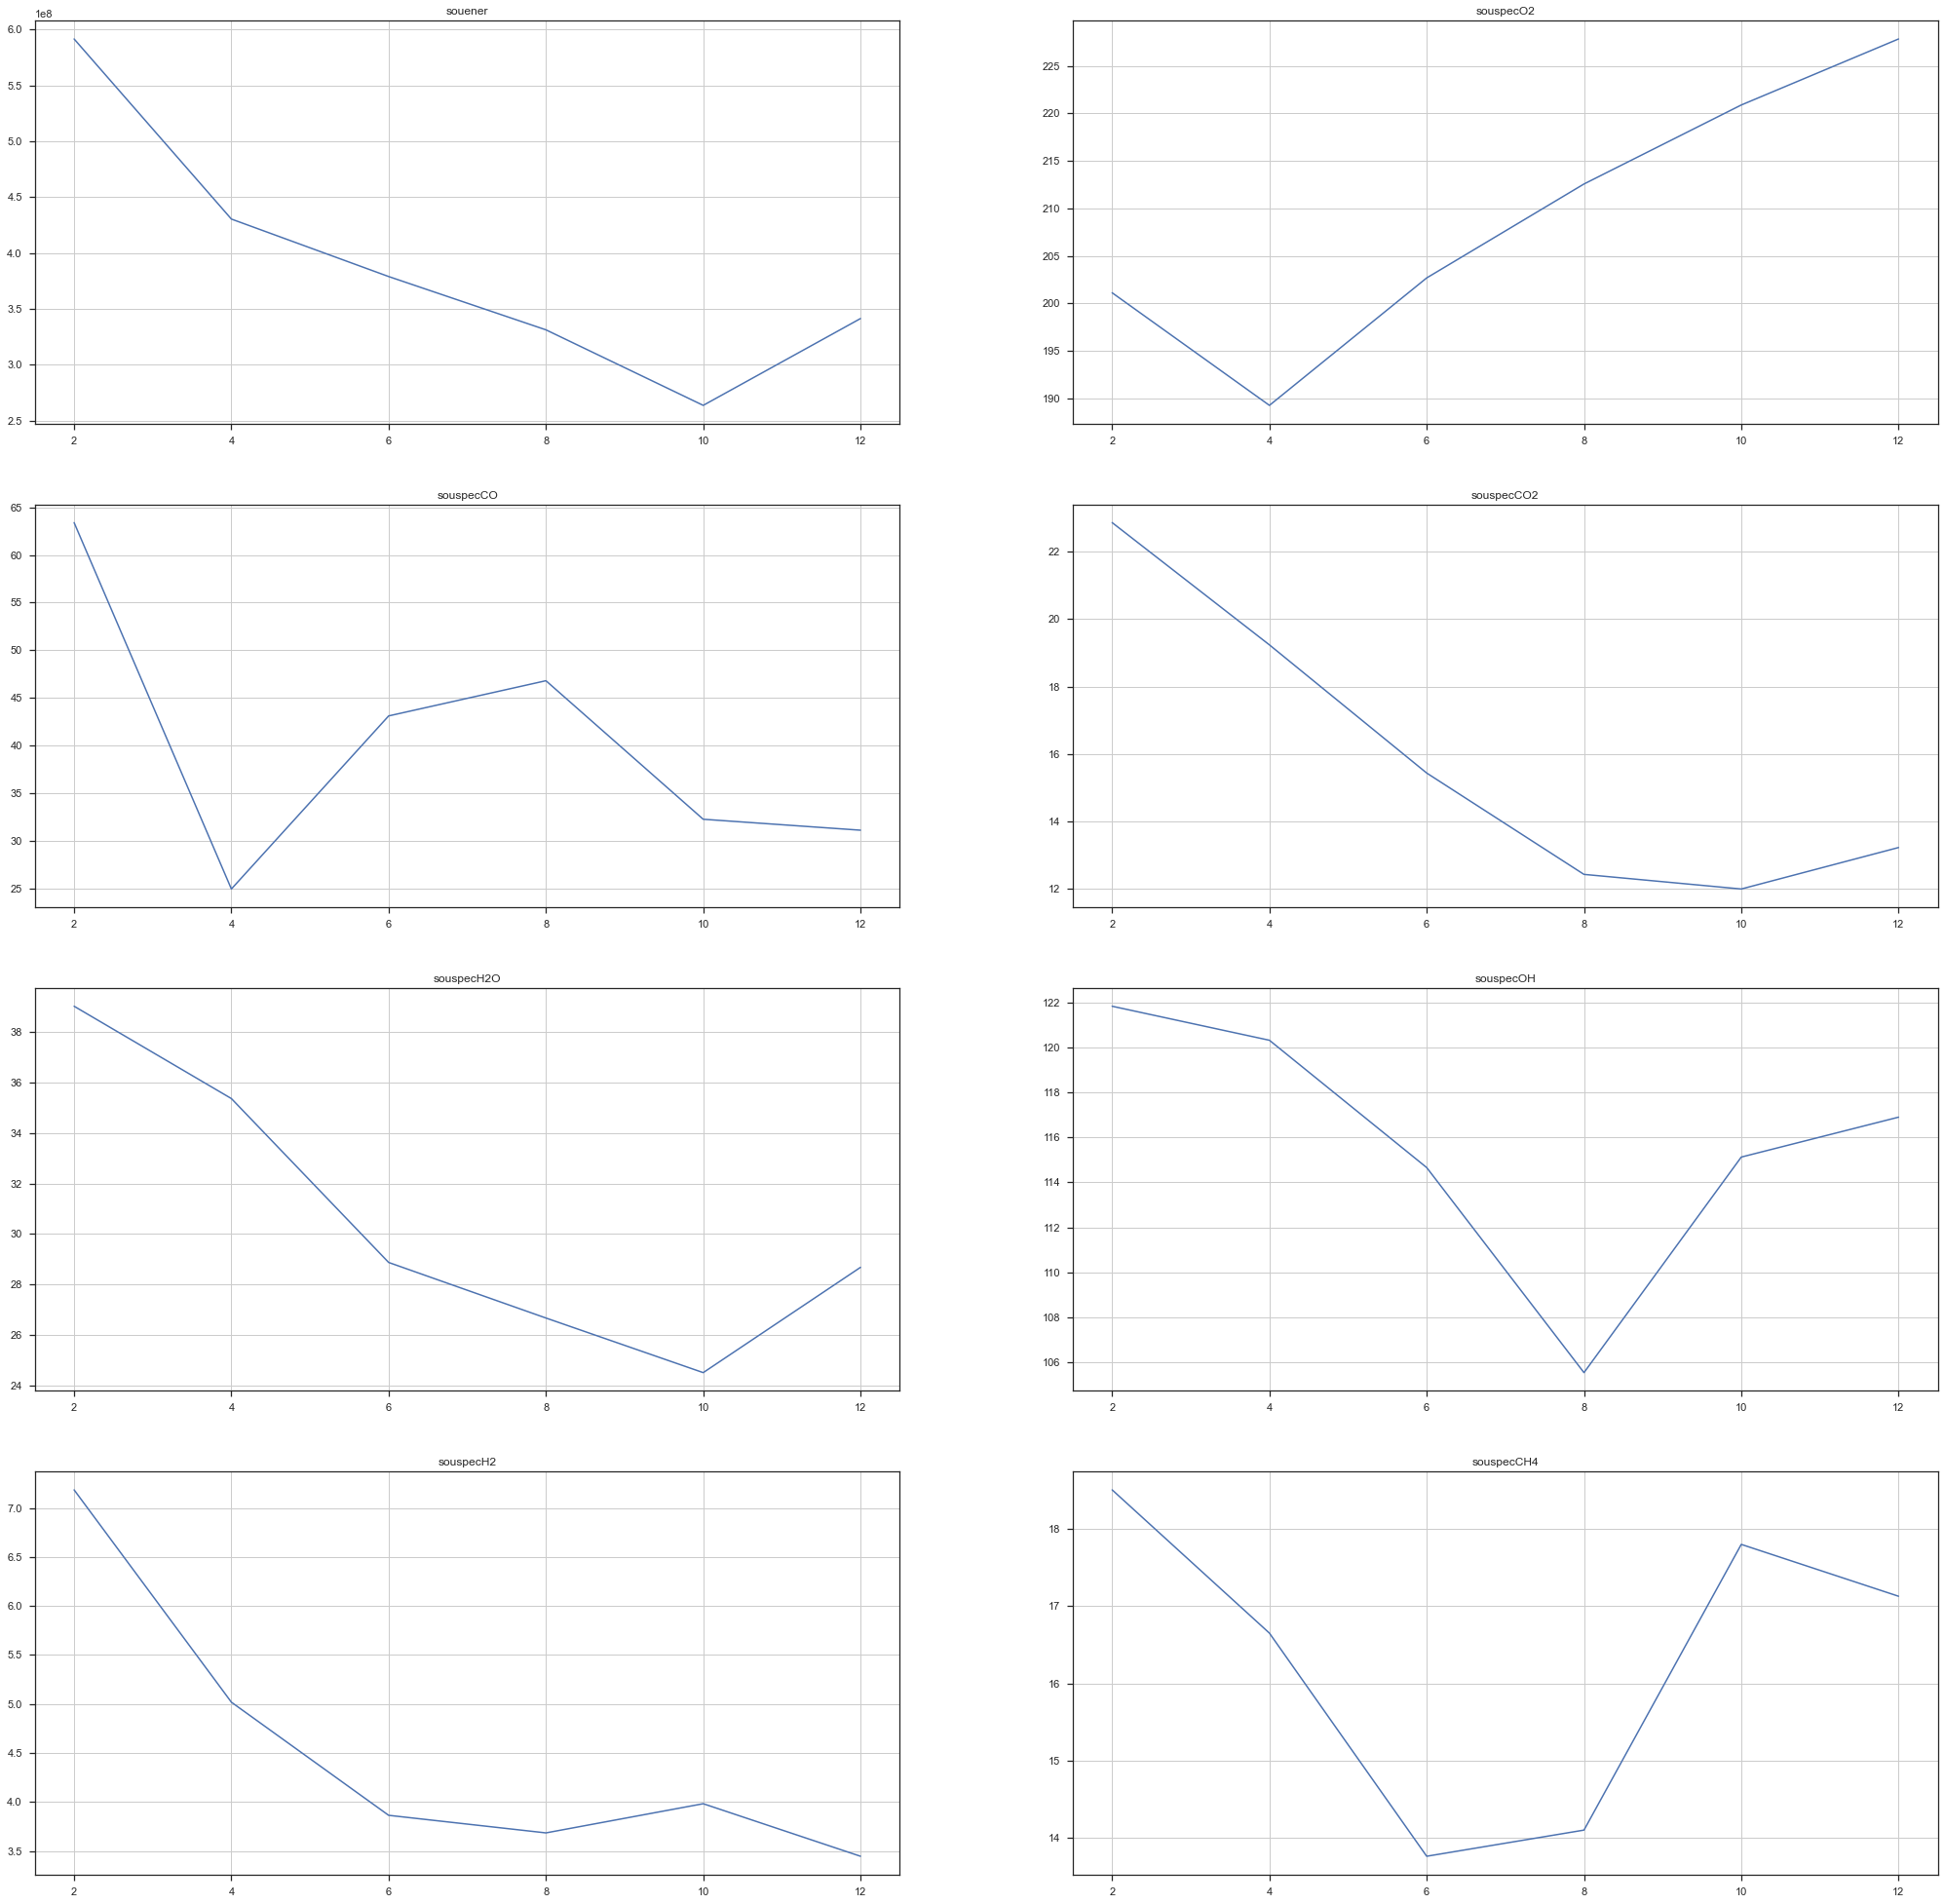

In [301]:
save_file_name= "plots/"+"ensemble_"+ split_strategy + "_ablation.tex"
plot_ensemble_ablation(ablation_by_dependent,dependents,n_members_ablation,save_file=save_file_name)

### Compute the Residuals on the Holdout Data for the Single Model by Flamelet and XPos

/Users/asalunkh/source_code/ChemTab/ChemTab/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


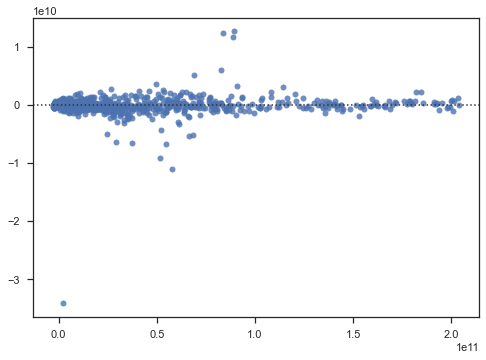

In [302]:
err_ensemble_df,Y_ensemble_true_df,Y_ensemble_pred_df = evaluate_model(regressor_ensembles[10],dataset,model_type='regressor',evaluation_type='test',ensemble=True)
sns.residplot(Y_ensemble_true_df["souener"].values, getResiduals(Y_ensemble_true_df["souener"].values,Y_ensemble_pred_df["souener"].values))
residual_ensemble_df = create_residual_df(Y_ensemble_pred_df,Y_ensemble_true_df,evaluation_type='test',residuals_for="souener")
high_res_flames_ensemble = residual_ensemble_df.groupby("flame_key_str")["residual_abs"].sum().sort_values(ascending=False)
#high_res_flames_ensemble

In [303]:
high_res_flames_ensemble_df = pd.DataFrame({'ABS Residual' : residual_ensemble_df.groupby("flame_key_str")["residual_abs"].sum().sort_values(ascending=False)}).reset_index()
high_res_flames_ensemble_df = high_res_flames_ensemble_df[high_res_flames_ensemble_df['flame_key_str'].isin(high_res_flames_df['flame_key_str'].values)]
high_res_flames_sm_de_df =  high_res_flames_df.merge(high_res_flames_ensemble_df, left_on='flame_key_str', right_on='flame_key_str', suffixes=("Single Model", "Deep Ensemble"))
high_res_flames_sm_de_df

,flame_key_str,ABS ResidualSingle Model,ABS ResidualDeep Ensemble
0,0.00023650,7.904599e+10,2.853646e+10
1,0.00020277,6.357353e+10,3.267808e+10
2,0.00033866,6.025435e+10,4.111402e+10
3,0.00030564,5.756831e+10,3.318879e+10
4,0.00022467,5.533021e+10,3.334996e+10
5,0.00039499,5.167164e+10,4.540711e+10
6,0.00032172,5.037682e+10,3.497139e+10
7,0.00027584,4.817240e+10,2.317479e+10
8,0.00024894,4.783312e+10,2.263936e+10
9,0.00021344,4.749524e+10,3.102894e+10


In [304]:
print(high_res_flames_sm_de_df.to_latex(index=False))

\begin{tabular}{lrr}
\toprule
flame\_key\_str &  ABS ResidualSingle Model &  ABS ResidualDeep Ensemble \\
\midrule
   0.00023650 &              7.904599e+10 &               2.853646e+10 \\
   0.00020277 &              6.357353e+10 &               3.267808e+10 \\
   0.00033866 &              6.025435e+10 &               4.111402e+10 \\
   0.00030564 &              5.756831e+10 &               3.318879e+10 \\
   0.00022467 &              5.533021e+10 &               3.334996e+10 \\
   0.00039499 &              5.167164e+10 &               4.540711e+10 \\
   0.00032172 &              5.037682e+10 &               3.497139e+10 \\
   0.00027584 &              4.817240e+10 &               2.317479e+10 \\
   0.00024894 &              4.783312e+10 &               2.263936e+10 \\
   0.00021344 &              4.749524e+10 &               3.102894e+10 \\
\bottomrule
\end{tabular}



In [305]:
high_res_Xpos_ensemble = residual_ensemble_df.groupby("Xpos_bins")["residual_abs"].sum().sort_values(ascending=False).head(10)


In [306]:
high_res_xpos_bins_ensemble_df = pd.DataFrame({'ABS Residual' : residual_ensemble_df.groupby("Xpos_bins")["residual_abs"].sum().sort_values(ascending=False)}).reset_index()
high_res_xpos_sm_de_df =  high_res_xpos_bins_df.merge(high_res_xpos_bins_ensemble_df, left_on='Xpos_bins', right_on='Xpos_bins', suffixes=("Single Model", "Deep Ensemble"))
high_res_xpos_sm_de_df

,Xpos_bins,ABS ResidualSingle Model,ABS ResidualDeep Ensemble
0,0.22 - 0.33,4.133929e+11,2.176143e+11
1,0.0 - 0.11,3.364565e+11,3.162390e+11
2,0.11 - 0.22,2.284694e+11,1.254176e+11
3,0.33 - 0.44,2.058881e+11,1.079951e+11
4,0.55 - 0.66,1.102133e+11,2.920763e+10
5,0.44 - 0.55,8.971007e+10,3.211109e+10
6,0.66 - 0.77,8.144498e+10,2.514758e+10
7,0.77 - 0.88,4.431664e+10,9.388437e+09
8,0.88 - 0.99,2.765116e+10,3.611705e+09
9,0.99 - 1.1,1.691913e+09,2.038095e+07


In [307]:
print(high_res_xpos_sm_de_df.to_latex(index=False)) 

\begin{tabular}{lrr}
\toprule
  Xpos\_bins &  ABS ResidualSingle Model &  ABS ResidualDeep Ensemble \\
\midrule
0.22 - 0.33 &              4.133929e+11 &               2.176143e+11 \\
 0.0 - 0.11 &              3.364565e+11 &               3.162390e+11 \\
0.11 - 0.22 &              2.284694e+11 &               1.254176e+11 \\
0.33 - 0.44 &              2.058881e+11 &               1.079951e+11 \\
0.55 - 0.66 &              1.102133e+11 &               2.920763e+10 \\
0.44 - 0.55 &              8.971007e+10 &               3.211109e+10 \\
0.66 - 0.77 &              8.144498e+10 &               2.514758e+10 \\
0.77 - 0.88 &              4.431664e+10 &               9.388437e+09 \\
0.88 - 0.99 &              2.765116e+10 &               3.611705e+09 \\
 0.99 - 1.1 &              1.691913e+09 &               2.038095e+07 \\
\bottomrule
\end{tabular}



In [308]:
cols = ["Dependent","Mean ABS"]
err_sm_de_df = err_df[cols].merge(err_ensemble_df[cols], left_on='Dependent', right_on='Dependent', suffixes=("Single Model", "Deep Ensemble"))
err_sm_de_df

,Dependent,Mean ABSSingle Model,Mean ABSDeep Ensemble
0,souener,4.707529e+08,2.635308e+08
1,souspecO2,1.942694e+02,2.208963e+02
2,souspecCO,3.386323e+01,3.229429e+01
3,souspecCO2,3.149259e+01,1.199201e+01
4,souspecH2O,3.850885e+01,2.450645e+01
5,souspecOH,1.294892e+02,1.151302e+02
6,souspecH2,9.871214e+00,3.982494e+00
7,souspecCH4,4.095063e+01,1.780133e+01


In [309]:
print(err_sm_de_df.to_latex(index=False)) 

\begin{tabular}{lrr}
\toprule
 Dependent &  Mean ABSSingle Model &  Mean ABSDeep Ensemble \\
\midrule
   souener &          4.707529e+08 &           2.635308e+08 \\
 souspecO2 &          1.942694e+02 &           2.208963e+02 \\
 souspecCO &          3.386323e+01 &           3.229429e+01 \\
souspecCO2 &          3.149259e+01 &           1.199201e+01 \\
souspecH2O &          3.850885e+01 &           2.450645e+01 \\
 souspecOH &          1.294892e+02 &           1.151302e+02 \\
 souspecH2 &          9.871214e+00 &           3.982494e+00 \\
souspecCH4 &          4.095063e+01 &           1.780133e+01 \\
\bottomrule
\end{tabular}



In [311]:
err_ensemble_df,Y_ensemble_true_df,Y_ensemble_pred_df = evaluate_model(regressor_ensembles[10],dataset,model_type='regressor',evaluation_type='test', ensemble=True)

err_df,Y_true_df,Y_pred_df = evaluate_model(regressor_model,dataset,model_type='regressor',evaluation_type='test')

cols = ["Dependent","Mean ABS"]
err_sm_de_df = err_df[cols].merge(err_ensemble_df[cols], left_on='Dependent', right_on='Dependent', suffixes=("Single Model", "Deep Ensemble"))
err_sm_de_df

print(err_sm_de_df.to_latex(index=False)) 

\begin{tabular}{lrr}
\toprule
 Dependent &  Mean ABSSingle Model &  Mean ABSDeep Ensemble \\
\midrule
   souener &          4.679949e+08 &           2.635308e+08 \\
 souspecO2 &          1.951080e+02 &           2.208963e+02 \\
 souspecCO &          3.353040e+01 &           3.229429e+01 \\
souspecCO2 &          3.011369e+01 &           1.199201e+01 \\
souspecH2O &          3.879371e+01 &           2.450645e+01 \\
 souspecOH &          1.280294e+02 &           1.151302e+02 \\
 souspecH2 &          9.770577e+00 &           3.982494e+00 \\
souspecCH4 &          4.241771e+01 &           1.780133e+01 \\
\bottomrule
\end{tabular}



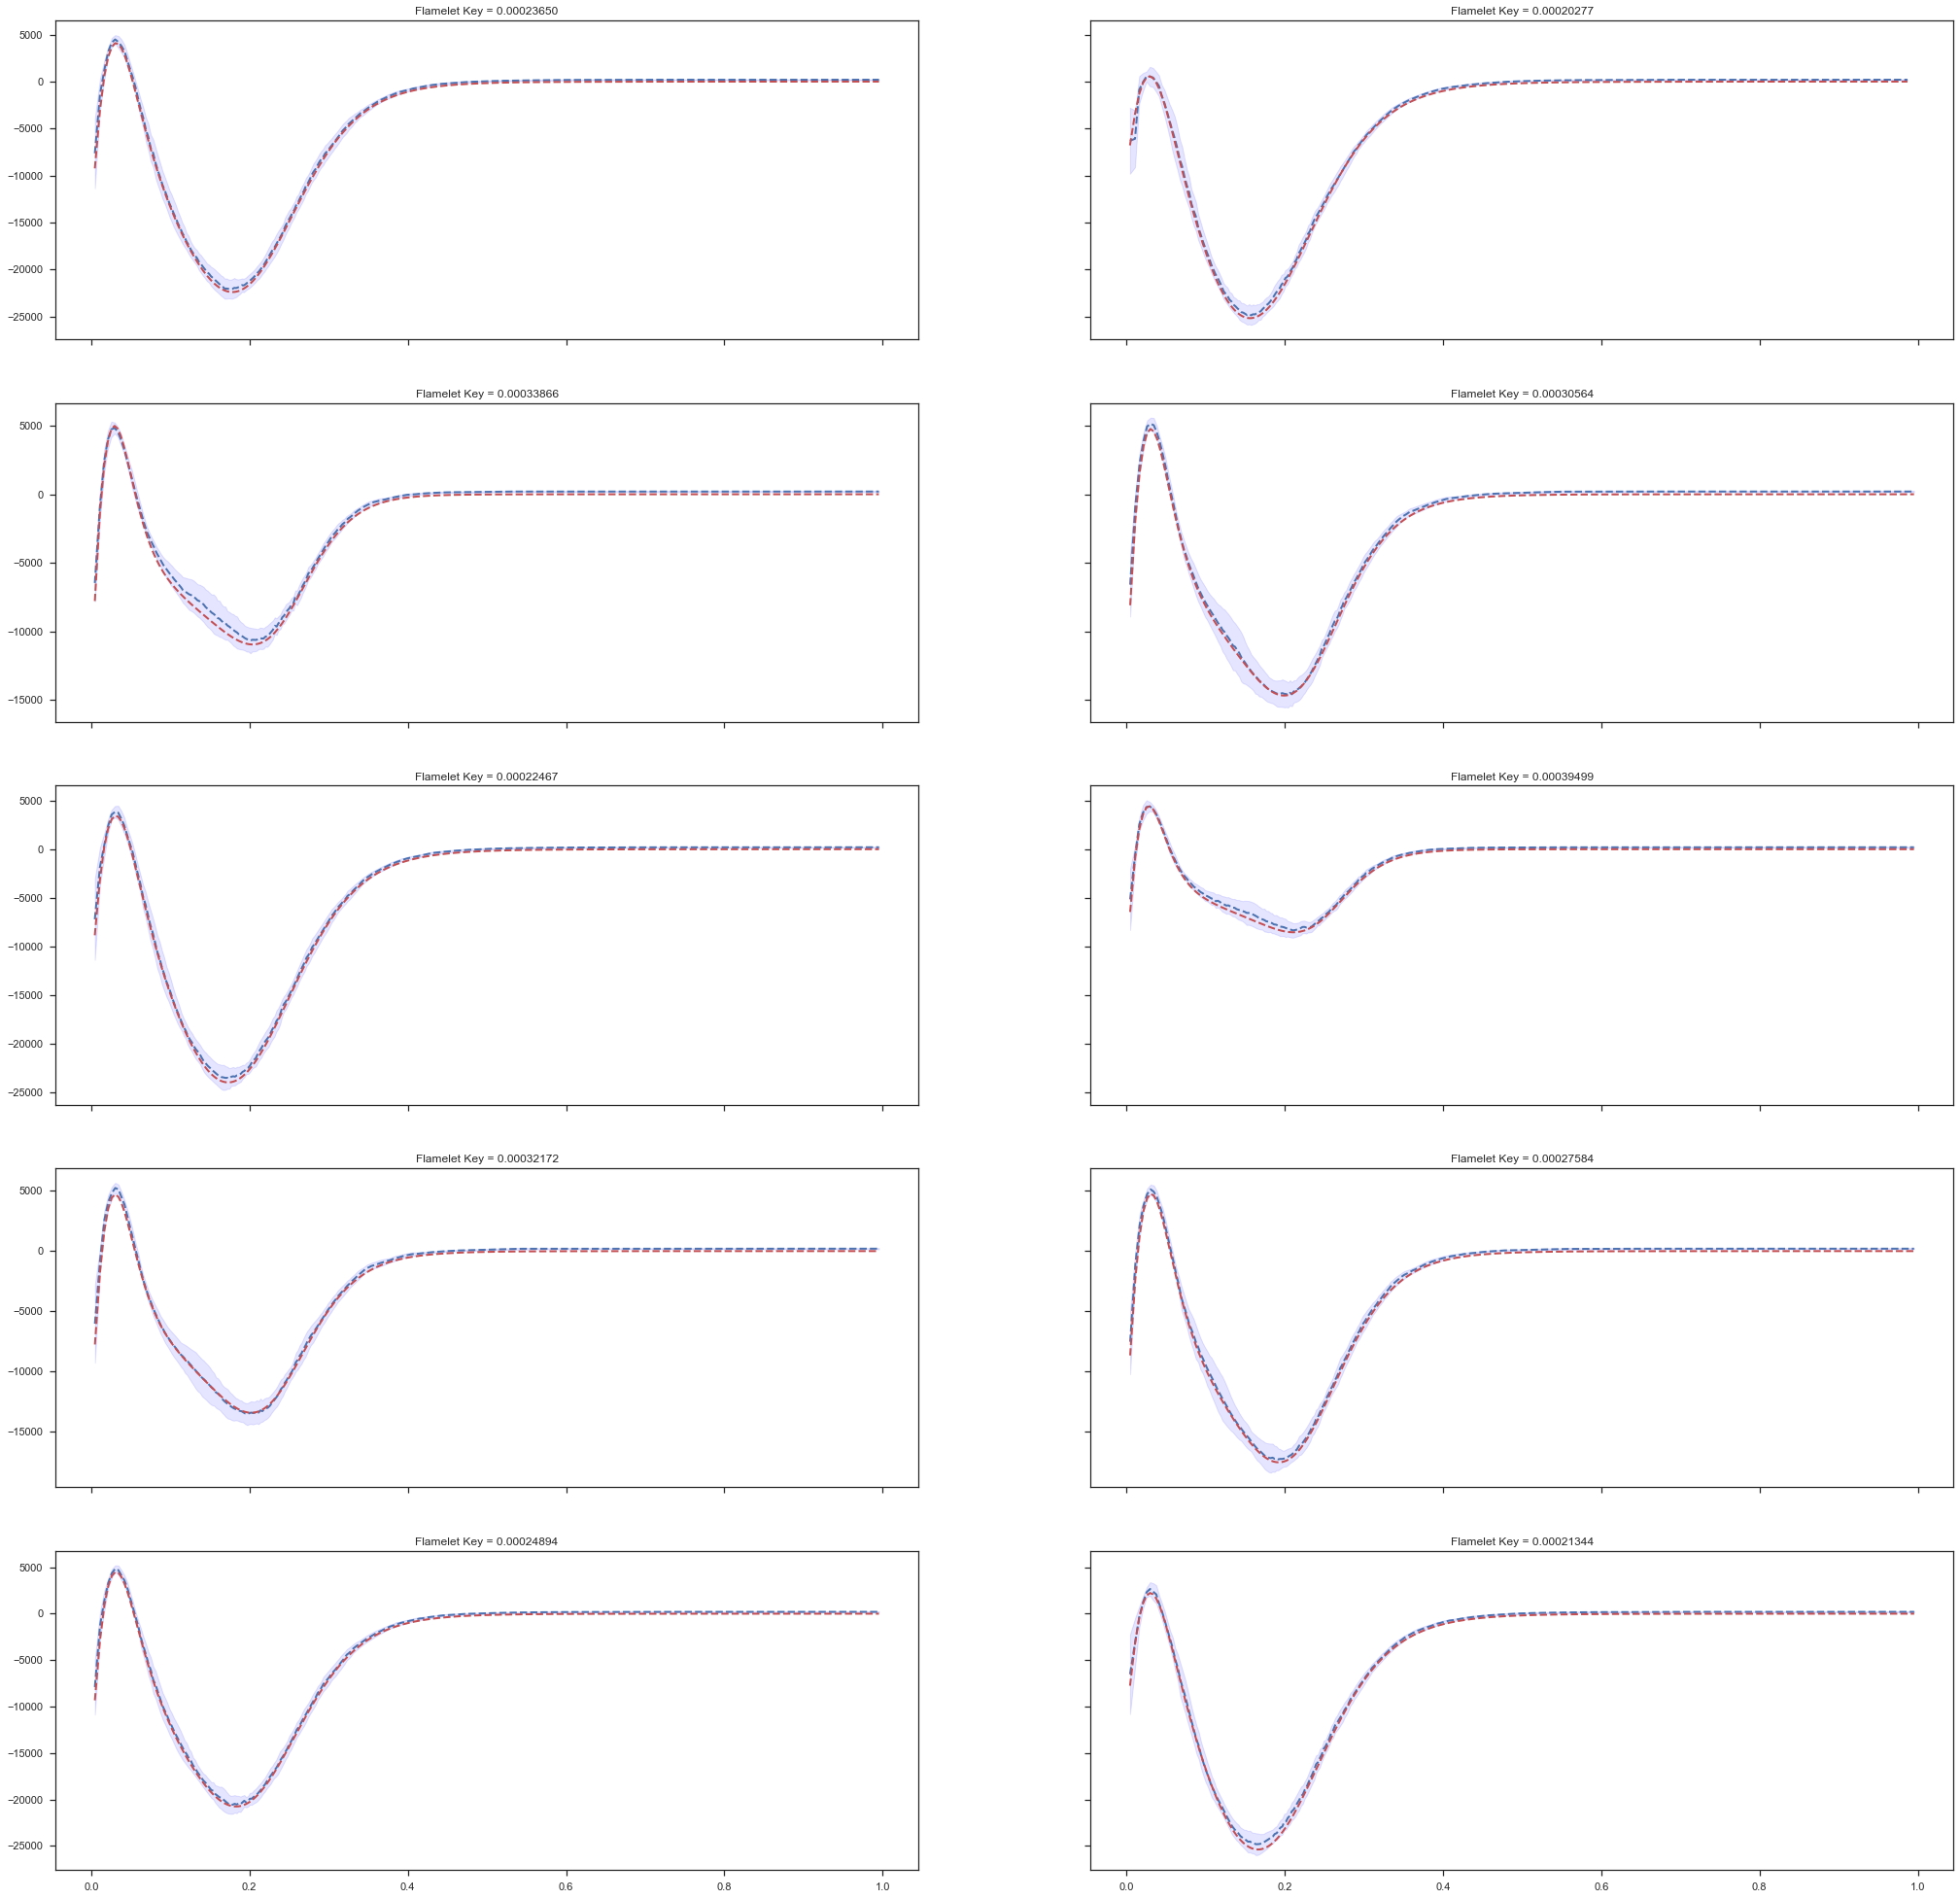

In [312]:
save_file_name = "plots/"+"ensemble_"+ split_strategy +"_flame_"+depenent_name+".tex"

err_ensemble_df,Y_ensemble_true_df,Y_ensemble_pred_df = evaluate_model(regressor_ensembles[10],dataset,model_type='regressor',evaluation_type='all', ensemble=True)

dataset_ensemble_df = curate_flame_plot_data(dataset,Y_ensemble_true_df,Y_ensemble_pred_df,depenent_name=depenent_name, ensemble=True)

plot_flames(high_res_flames,dataset_ensemble_df,rows=5,cols=2,figsize=(35,35),true_col =depenent_name,pred_col =depenent_name+"_pred",x_axis_col="Xpos",upper_limit_col="upper_limit",lower_limit_col="lower_limit", ensemble=True,  save_file=save_file_name)




In [313]:
ensemble_dataset_df = curate_plot_data_for_all_dependents_for_a_flame(dataset,Y_ensemble_true_df,Y_ensemble_pred_df,ensemble=True)

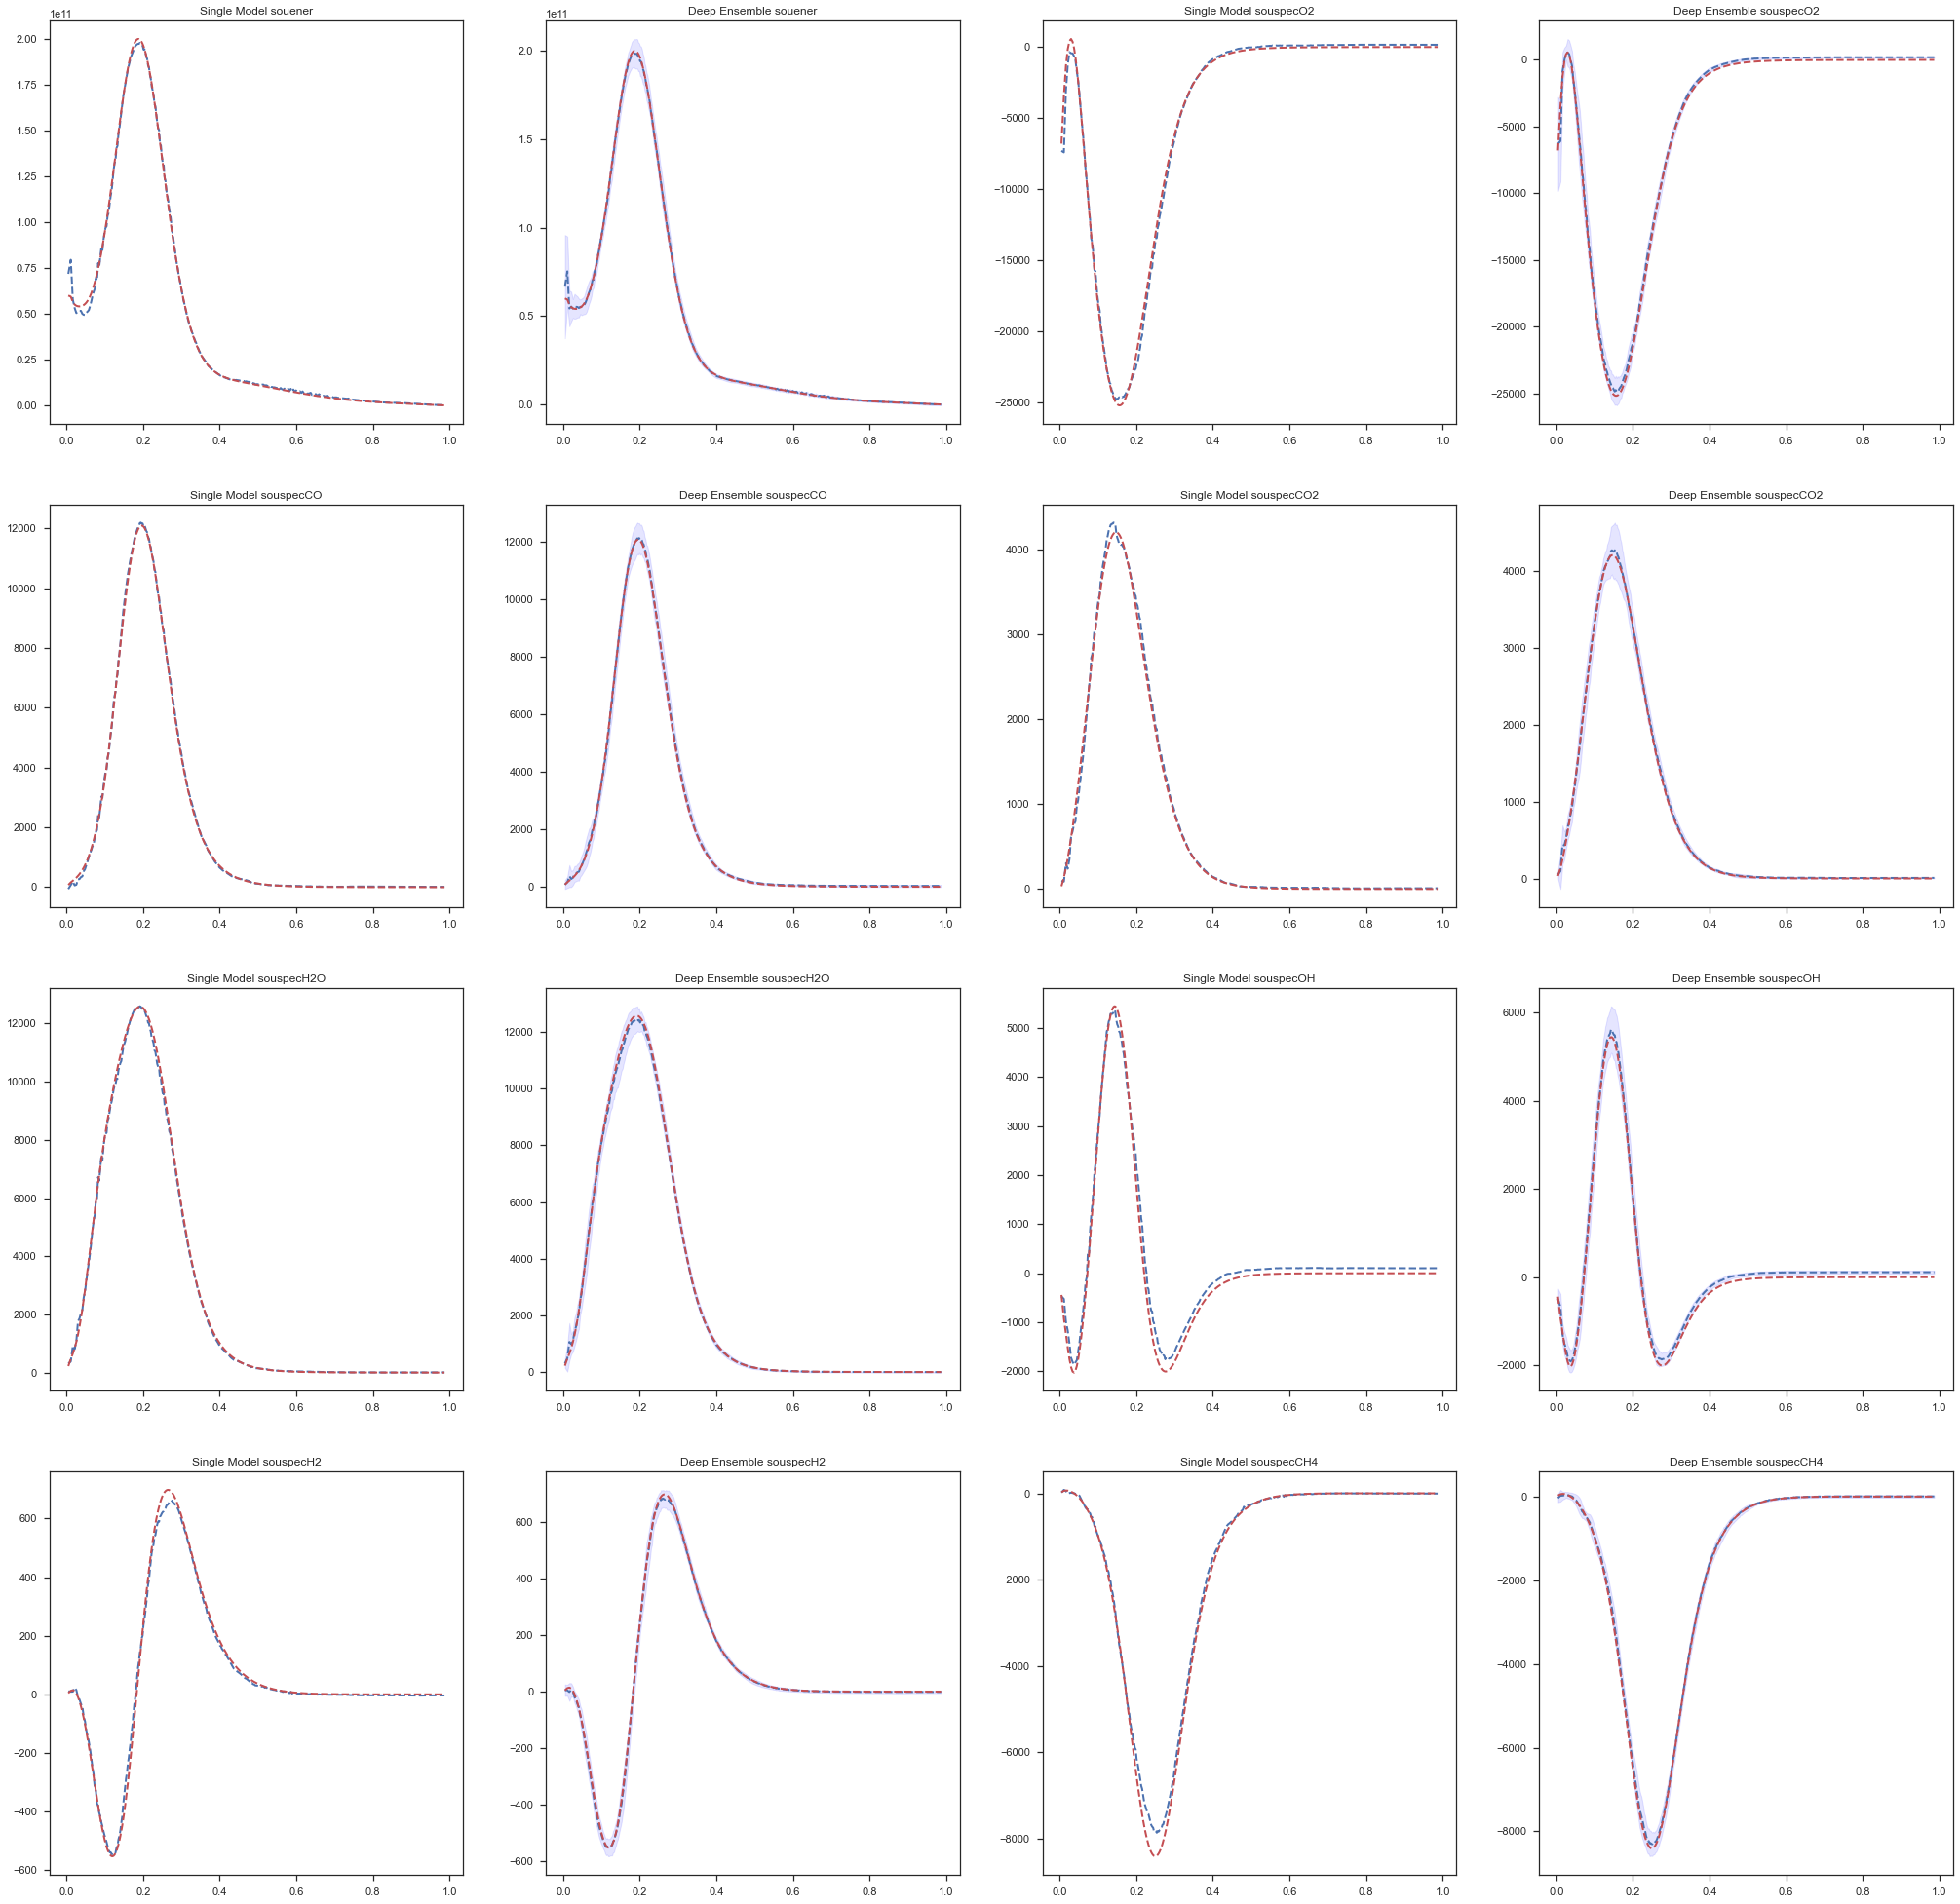

In [315]:
flame_key = '0.00020277'#-->points_strategy '0.00023650','0.00020277'    #-->flames_strategy '0.00024894'#'0.00046070'
save_file_name = "plots/"+"flamelet_"+ flame_key.replace('.','_') +'_'+split_strategy+".tex"
plot_single_model_vs_ensemble_for_a_flame(flame_key,single_model_dataset_df,ensemble_dataset_df,
                rows=4,cols=4,figsize=(35,35),x_axis_col="Xpos", save_file=save_file_name)